<a href="https://colab.research.google.com/github/nainikadevireddy/JohnsHopkinsAI/blob/main/Deep%20Neural%20Networks/9%3A%20Venus%20Mars%20Competition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<small><font color=gray>Notebook author: <a href="https://www.linkedin.com/in/olegmelnikov/" target="_blank">Oleg Melnikov</a> ©2021 onwards</font></small><hr style="margin:0;background-color:silver">

**<font size=6>🪐Venus vs Mars</font>**. [**Instructions**](https://colab.research.google.com/drive/1riOGrE_Fv-yfIbM5V4pgJx4DWcd92cZr#scrollTo=ITaPDPIQEgXV) for running Colabs.

<details>
  <summary><small>Sharing consent: <mark>[ X ]</mark></summary>
  <div>
We consent to sharing our Colab (after the assignment ends) with other students/instructors for educational purposes. We understand that sharing is <b>optional</b> and this decision will not affect our grade in any way. <font color=gray><i>
Instructions: If ok with sharing your Colab for educational purposes, leave "X" in the check box.</i></font></small></div>

In [ ]:
# from google.colab import drive; drive.mount('/content/drive')   # OK to enable, if kaggle.json is stored in Google Drive

In [ ]:
!pip install --upgrade --force-reinstall --no-deps kaggle >> log  # upgrade kaggle package (to avoid a warning)
!mkdir -p ~/.kaggle                               # .kaggle folder must contain kaggle.json for kaggle executable to properly authenticate you to Kaggle.com
!cp /content/drive/MyDrive/kaggle.json ~/.kaggle/kaggle.json >log  # First, download kaggle.json from kaggle.com (in Account page) and place it in the root of mounted Google Drive
!cp kaggle.json ~/.kaggle/kaggle.json > log       # Alternative location of kaggle.json (without a connection to Google Drive)
!chmod 600 ~/.kaggle/kaggle.json                  # give only the owner full read/write access to kaggle.json
!kaggle config set -n competition -v 17mar25-venus-vs-mars # set the competition context for the next few kaggle API calls. !kaggle config view - shows current settings
!kaggle competitions download >> log              # download competition dataset as a zip file
!unzip -o *.zip >> log                            # Kaggle dataset is copied as a single file and needs to be unzipped.
!kaggle competitions leaderboard --show           # print public leaderboard

cp: cannot stat '/content/drive/MyDrive/kaggle.json': No such file or directory
- competition is now set to: 17mar25-venus-vs-mars
Using competition: 17mar25-venus-vs-mars
  teamId  teamName                    submissionDate              score         
--------  --------------------------  --------------------------  ------------  
13603314  Group2_Jenelle_Shailesh     2025-04-06 00:07:54.126000  0.9756000000  
13600183  Team14_Nainika_Austin       2025-04-05 17:14:12.313000  0.9580000000  
13586911  Cristhian de Moraes Venero  2025-04-04 04:01:44.266000  0.9576000000  
13554394  ChipHenderson93             2025-04-06 00:54:50.893000  0.9540000000  
13593040  Josh Redmond                2025-04-05 23:52:37.733000  0.9536000000  
13579081  9 Simmons Ziaei             2025-04-06 02:09:20.373000  0.9496000000  
13581431  Josh Gompert                2025-04-05 17:11:54.970000  0.9488000000  
13587916  Jenelle Millison            2025-04-05 21:21:45.336000  0.9424000000  
13592898  10_jungw

See [more](https://nvidia.custhelp.com/app/answers/detail/a_id/3751/~/useful-nvidia-smi-queries) about NVIDIA GPU stats. Test your code in (free) Colab. It uses Tesla K80 GPU.

In [ ]:
!nvidia-smi --query-gpu=gpu_name,memory.total,memory.free,memory.used --format=csv

name, memory.total [MiB], memory.free [MiB], memory.used [MiB]
Tesla T4, 15360 MiB, 15095 MiB, 0 MiB


In [ ]:
%%time
%%capture
%reset -f
!pip install -U tfds-nightly tensorflow keras tensorflow_addons plotly >> log  # update tfa in case students need to use it
from IPython.core.interactiveshell import InteractiveShell as IS; IS.ast_node_interactivity = "all"
import numpy as np, pandas as pd, time, matplotlib.pyplot as plt, os
import tensorflow as tf, tensorflow.keras as keras, tensorflow_datasets as tfds # tensorflow_addons as tfa
from keras.layers import Flatten, Dense, Dropout, MaxPooling2D, Conv2D, GlobalAveragePooling2D
from keras.models import Sequential
from tensorflow.keras.applications import resnet50, xception, mobilenet, mobilenet_v2, mobilenet_v3
from tensorflow.keras.utils import image_dataset_from_directory as idfd
os.environ['TF_DETERMINISTIC_OPS'] = '1'; os.environ['TF_CUDNN_DETERMINISTIC'] = '1'; # allows seeding RNG on GPU
ToCSV = lambda df, fname: df.round(2).to_csv(f'{fname}.csv', index_label='id') # rounds values to 2 decimals

class Timer():
  def __init__(self, lim:'RunTimeLimit'=60*5): self.t0, self.lim, _ = time.time(), lim, print(f'⏳ started. You have {lim} sec. Good luck!')
  def ShowTime(self):
    msg = f'Runtime is {time.time()-self.t0:.0f} sec'
    print(f'\033[91m\033[1m' + msg + f' > {self.lim} sec limit!!!\033[0m' if (time.time()-self.t0-1) > self.lim else msg)

np.set_printoptions(linewidth=100, precision=2, edgeitems=5, suppress=True)
pd.set_option('display.max_columns', 20, 'display.precision', 2, 'display.max_rows', 4)
tDIR, sDIR = 'train/', 'test/'

CPU times: user 4.61 s, sys: 810 ms, total: 5.42 s
Wall time: 1min 43s


Examples of images from female class

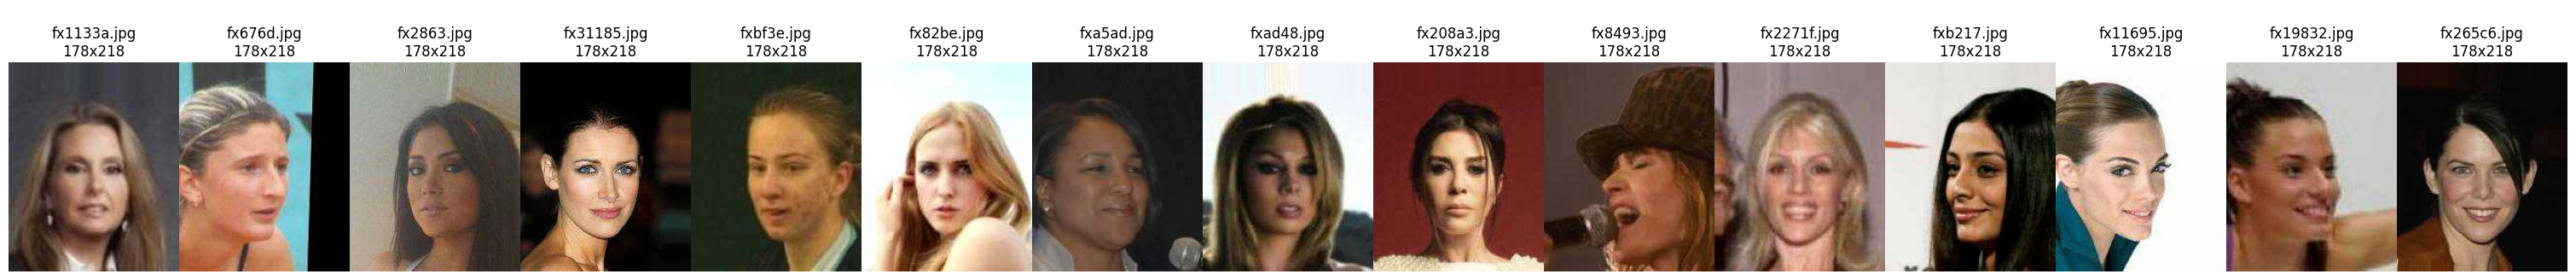

In [ ]:
n, fig = 15, plt.figure(figsize=(30,10));
for i, f in enumerate(np.random.RandomState(0).choice(os.listdir(tDIR+'female/'), n)):
  ax = plt.subplot(1, n, i + 1)
  img = keras.preprocessing.image.load_img(tDIR+'female/'+f);
  _ = ax.set_title(f'\n{f}\n{img.size[0]}x{img.size[1]}');
  _ = plt.axis('off');   _ = plt.tight_layout(pad=0);   _ = plt.imshow(img);

Examples of images from male class

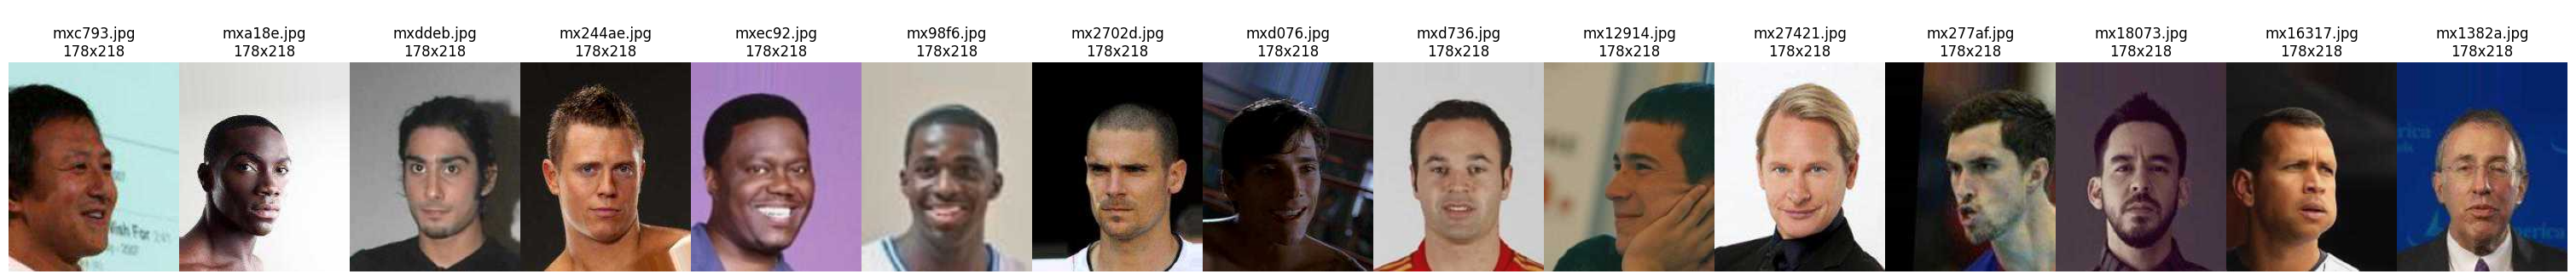

In [ ]:
n, fig = 15, plt.figure(figsize=(30,10));
for i, f in enumerate(np.random.RandomState(0).choice(os.listdir(tDIR+'male/'), n)):
  ax = plt.subplot(1, n, i + 1)
  img = keras.preprocessing.image.load_img(tDIR+'male/'+f);
  _ = ax.set_title(f'\n{f}\n{img.size[0]}x{img.size[1]}');
  _ = plt.axis('off');   _ = plt.tight_layout(pad=0);   _ = plt.imshow(img);

In [ ]:
tmr = Timer() # runtime limit (in seconds). Add all of your code after the timer

⏳ started. You have 300 sec. Good luck!


<hr color=green size=40>

<strong><font color=green size=5>⏳Timed Green Playground (TGP): Your ideas, code, documentation, and timer START HERE!</font></strong>

<font color=green>Students: Keep all your definitions, code, documentation in <b>TGP</b>. Modifying any code outside of TGP incurs penalties.

<font color=green><h4><b>Import Necessary Libraries</b></h4>

In [ ]:
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from sklearn.utils import shuffle

<font color=green><h4><b>Load Training Data</b></h4>

In [ ]:
# Set-Up
tDIR = 'train/'
sDIR = 'test/'
IMG_SIZE = (224, 224)
BS = 64
EPOCHS = 10

# Load training data
filepaths = np.array(sorted(tf.io.gfile.glob(tDIR + '*/*.jpg')))
labels = np.array([0 if 'female' in path else 1 for path in filepaths])

filepaths, labels = shuffle(filepaths, labels, random_state=0)
labels = np.array(labels)

<font color=green><h4><b>Build Training Dataset</b></h4>

In [ ]:
# Build training dataset
def make_tf_dataset(paths, labels=None, batch_size=BS, img_size=IMG_SIZE, training=True):
    def process(path, label=None):
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, img_size)
        img = preprocess_input(img)
        if label is None:
            return img
        return img, tf.reshape(tf.cast(label, tf.float32), (1,))

    if labels is not None:
        ds = tf.data.Dataset.from_tensor_slices((paths, labels))
        ds = ds.map(lambda x, y: process(x, y), num_parallel_calls=tf.data.AUTOTUNE)
    else:
        ds = tf.data.Dataset.from_tensor_slices(paths)
        ds = ds.map(process, num_parallel_calls=tf.data.AUTOTUNE)

    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

train_ds = make_tf_dataset(filepaths, labels)

<font color=green><h4><b>Build Model</b></h4>

In [ ]:
# Build Model
def build_model(input_shape=(224, 224, 3)):
    base_model = EfficientNetB0(include_top=False, weights='imagenet', input_shape=input_shape)

    # Freeze all but last 30 layers
    for layer in base_model.layers[:-80]:
        layer.trainable = False
    for layer in base_model.layers[-80:]:
        layer.trainable = True

    inputs = keras.Input(shape=input_shape)
    x = base_model(inputs, training=True)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = keras.Model(inputs, outputs)

    lr_schedule = keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=1e-4,
        decay_steps=100,
        decay_rate=0.9
    )
    optimizer = keras.optimizers.Adam(learning_rate=lr_schedule)

    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model

model = build_model()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


<font color=green><h4><b>Train Model</b></h4>

In [ ]:
# Train Model
early_stop = keras.callbacks.EarlyStopping(monitor='loss', patience=3, restore_best_weights=True)

model.fit(train_ds, epochs=EPOCHS, callbacks=[early_stop], verbose=1)

Epoch 1/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 43s 196ms/step - accuracy: 0.7630 - loss: 0.4877
Epoch 2/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 16s 202ms/step - accuracy: 0.9379 - loss: 0.1776
Epoch 3/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 16s 202ms/step - accuracy: 0.9611 - loss: 0.1160
Epoch 4/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 21s 205ms/step - accuracy: 0.9780 - loss: 0.0768
Epoch 5/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 20s 203ms/step - accuracy: 0.9841 - loss: 0.0515
Epoch 6/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 16s 205ms/step - accuracy: 0.9913 - loss: 0.0358
Epoch 7/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 16s 201ms/step - accuracy: 0.9928 - loss: 0.0268
Epoch 8/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 21s 204ms/step - accuracy: 0.9962 - loss: 0.0183
Epoch 9/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 16s 203ms/step - accuracy: 0.9957 - loss: 0.0173
Epoch 10/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 16s 203ms/step - accuracy: 0.9981 - loss: 0.0121


<font color=green><h4><b>Build Test Dataset and Predict</b></h4>

In [ ]:
# Build Test Set
test_paths = sorted(tf.io.gfile.glob(sDIR + '*.jpg'))
sDS = make_tf_dataset(test_paths, labels=None)

# Parse image IDs from filenames
vIDs = [os.path.basename(f).split('.')[0] for f in test_paths]

# Predict and save
pY = pd.DataFrame(model.predict(sDS), index=vIDs, columns=['y'])
ToCSV((pY > 0.5) * 1, 'final_attempt')

79/79 ━━━━━━━━━━━━━━━━━━━━ 16s 166ms/step


# Venus/Mars Documentation  
**Group 14**

---

## Title: Model Selection

**Idea Discovery:**  
The baseline Starter Colab used a MobileNetV2 model pre-trained on ImageNet, frozen except for the final layer, achieving 0.401 on the leaderboard. We explored both custom CNNs and pretrained EfficientNet architectures to improve performance. EfficientNet B0, B1, and B3 were considered.

**Finding's Importance:**  
Model selection significantly influences the efficiency and accuracy of computer vision tasks. MobileNetV2 and EfficientNet are both lightweight CNN architectures designed for efficient image classification, but they differ in design and performance. MobileNetV2, introduced in 2018, was optimized for mobile and edge devices using inverted residuals and linear bottlenecks to reduce latency and model size [1]. EfficientNet, released in 2019, uses a compound scaling method to uniformly scale depth, width, and resolution, achieving better accuracy with fewer parameters [1]. While MobileNetV2 excels in speed and simplicity for low-resource environments, EfficientNet is more versatile and offers significantly higher performance. Both models are pre-trained on ImageNet, suggesting significant exposure to relevant features in the competition dataset [1].

**Experiment Setup:**  
We first implemented a custom CNN with three convolutional blocks, max-pooling, and dropout, followed by a dense classification head. We trained this using a 5-fold cross-validation setup and tracked average fold accuracy and standard deviation. After optimizing the CNN, we tested pre-trained EfficientNetB0 and B1 models. For each pretrained model, we unfreezed either the last 20 layers, applied a learning rate schedule (Exponential Decay), and used early stopping (patience=3). All models were trained on shuffled image data resized to 160×160. Final validation accuracies were compared across models.

**Results:**  
The custom CNN achieved a cross-validation accuracy of 0.853. Meanwhile, EfficientNetB0 achieved a cross-validation accuracy of 0.913, scoring 0.9332 on the Kaggle public leaderboard. EfficientNet B1 and B3 took more than 300 seconds to run; hence was not considered for further exploration.

---

## Title: Number of Frozen Layers

**Idea Discovery:**  
During fine-tuning of EfficientNet models, we investigated how many layers should remain frozen to balance generalization and task-specific adaptation. The pretrained network contains rich low-level features from ImageNet, but freezing too much prevents learning dataset-specific facial features, while unfreezing too much risks overfitting.

**Finding's Importance:**  
EfficientNet’s architecture is highly modular, with earlier layers capturing basic patterns, such as edges and textures, and later layers representing higher-level semantics [2]. Selecting how many layers to unfreeze is critical in transfer learning, especially when the dataset is relatively small or homogenous. The number of trainable layers impacts not only performance but also training time and generalization. Finding the right balance improves convergence, reduces overfitting, and makes better use of the pretrained weights.

**Experiment Setup:**  
We tested EfficientNetB0 by unfreezing 10, 20, 30, 50, 80, and all 100 layers while using the same learning rate schedule (Exponential Decay), early stopping (patience = 3), and 160×160 resized images. All experiments used a batch size of 64 and were trained in a 5-fold cross-validation setup. Each configuration was monitored for both validation accuracy and signs of overfitting. Training times and fold-to-fold consistency were also recorded.

**Results:**  
Unfreezing only the last 10 or 20 layers improved performance slightly over the frozen baseline but plateaued at around 0.89–0.91 validation accuracy. Unfreezing 30 and 50 layers showed gradual gains, but the most significant improvement occurred at 80 layers, which yielded a cross-validation accuracy of 0.9653 and a leaderboard score of 0.9564. Unfreezing 100 layers resulted in similar accuracy but increased training time substantially and showed early signs of overfitting on some folds. Based on performance and efficiency, unfreezing the last 80 layers was selected as the optimal strategy for final model training.

---

## Title: Training Epochs

**Idea Discovery:**  
As part of optimizing model performance and runtime within the 300 second competition limit, we explored and fine-tuned the effect of the number of epochs on the model performance and runtime.

**Finding's Importance:**  
Selecting the appropriate number of training epochs directly impacts both validation performance and compliance with runtime restrictions. Too few epochs result in underfitting and poor generalization, while too many may cause overfitting or running overtime.

**Experiment Setup:**  
We trained EfficientNetB0 models using 5-fold cross-validation, testing epoch counts of 10, 11, 12, 13, 14, and 15. All runs used the same optimizer, learning rate decay, and early stopping (patience = 3). We monitored validation accuracy and the training duration per fold to assess performance within the time constraint.

**Results:**  
Models trained with 15 epochs achieved the best validation accuracy across folds, but exceeded the 300-second runtime limit. Epochs 13 and 14 also showed strong performance but ran over the time limit. Under the 300-second limit, 12 epochs achieved the best validation accuracy across folds, scoring 0.9580 on the public leaderboard, but had an average runtime of 286 seconds, running very close to the runtime limit. 10 epochs were chosen as a trade-off between accuracy and the margin between average runtime and the runtime limit.

---

## Title: Manual Dataset Preprocessing Pipeline Using `tf.data`

**Idea Discovery:**  
We chose to implement our dataset loader manually using TensorFlow’s low-level image loading APIs instead of relying on higher-level tools like image_dataset_from_directory. This gave us precise control over file reading, resizing, and input normalization.

**Finding's Importance:**  
Manual data loading allowed us to shuffle data explicitly and apply preprocess_input() for the EfficientNet family for better normalization. Also, we were able to avoid unexpected batch behavior from auto-loaded datasets. This gave us reproducibility and flexibility in tuning other components of the training pipeline.

**Experiment Setup:**  
We implemented a custom data pipeline using tf.data. Images were resized to 224x224 and normalized using preprocess_input(0 from EfficientNet to align with the model’s ImageNet pretraining. This helped improve consistency and performance. A match size of 64 was chosen for its balance between training speed and memory usage. The dataset was shuffled and prefeteched to optimize runtime, keeping us within the competition’s time limit while ensuring efficient and reproducible training.


**Results:**  
This setup produced stable and reproducible results with minimal memory overhead. It integrated smoothly into our final model pipeline and helped us meet runtime requirements


---

## References

1. Lepelaars, C. (2020, August 14). *The evolution of Mobile CNN Architectures*. W&B. [Link](https://wandb.ai/carlolepelaars/mobile_architectures/reports/The-Evolution-Of-Mobile-CNN-Architectures--VmlldzoyMDQ0ODQ)  
2. Herath, S. (2024, January 13). *EfficientNetB0 Architecture – Stem Layer*. Medium. [Link](https://medium.com/image-processing-with-python/efficientnetb0-architecture-stem-layer-496c7911a62d)


<font color=green><h3><b>$\zeta$. Idea Documentation</b></h3>
<details>
  <summary>Instructions</summary>
  <div>


1. **Audience**. Your peers who will learn from your Colab and ideas therein.
1. **Importance**. The ML/DL ideas are not entirely random, but are based on prior experience and systematized/organized experiments. We'd like students to share and learn from idea generation to idea experimentation process done in our class using tools learned thus far.
1. **Format**. Keep it concise/precise in consistent font/presentation. Include numbers/IDs to your References, such as [1] or [[Géron22]](https://scholar.google.com/scholar?cluster=498861685923226475), where these are defined in your References section below. This helps link your ideas/experiments to external ideas.
1. **Reproducibility**. Your description should contain reasonable details needed for reproducibility, i.e. describe the state of your modeling pipeline before the change is made, what is changed and how the idea was discovered, and what improvement it resulted in. Thus, peers can try this idea with an expectation of the value it brings. See examples below.
1. **Bonus** points for the exceptional/exemplary/educational documentation (see grading rubric).
****
1. **TODO**: Describe the key idea in your work in the following format (similar to a "micro publication"):
  1. **Title**. Give each idea a descriptive name (i.e. a micro abstract).
    1. Ex(ample). <i>"Thresholding carat feature outliers improves MAE by 3% on public LB"</i>
  1. **Idea Discovery**. What led you to this idea? Was it some [EDA](https://en.wikipedia.org/wiki/Exploratory_data_analysis), familiarity with this dataset or some of the features?
    1. Ex. <i>"We plotted all univariate distributions of variables and discovered that diamond carat had unreasonable (but rare) values below and above [0,10] interval, when plotted carat's histogram in the train and test sets, which contained 10 and 3 such outliers respectively. We decided to use 10 as a reasonable threshold because it is 99th percentile of carat values in the 20K baseline sample. See our histogram plot below [plot here]. "</i>
  1. **Finding's Importance**. Describe why you think the idea was important to proceed with.
    1. Ex. <i>"We use a linear model, the slope of which is sensitive to outliers on the periphery of the feature space domain. The fitted hyperplane slopes in the direction of the extreme training feature values thereby mapping a non-existent relation between carat size and diamond price, which is not expected to repeat in the test set. "</i>
  1. **Experiment Setup**.
  How did you set up experiments to test your idea? What resources were helpful? What metric did you select, why and what values did you observe?
    1. Ex. <i>"To alleviate the impact of the outlying feature values, we need to either remove observations with extreme values, or somehow cap them (to stay within the distribution of the other carat values) or use a model insensitive to outliers (such as robust regression). We learned 3 suitable methods for treating outliers in [ref]: ... [It'd be great to briefly describe each method] We tried each one on a Baseline model, while keeping the competition-required [MAE](https://en.wikipedia.org/wiki/Mean_absolute_error) metric. We tested each method locally on the seeded 50/50 split of the 20K training set sampled in baseline Colab."</i>
  1. **Results**. What was the result or metric improvement from implementing the experiment locally and/or on public LB?
    1. Ex. <i>"Baseline MAE was 539.1257546465 in public LB and 530 in local default experiment with 50/50 train-test split. When applied on the same-seed split, Methods 1,2,and 3 showed 1%, 2%, and 5% improvement on the test set. When uploaded to public LB, Method 3 showed a 3% improvement. So, we decided to keep method 3."</i>

</div> </details>
</font>


<font color=green><h4><b>Task 1. Preprocessing Ideas</b></h4>
<details>
  <summary>Instructions</summary>
  <div>Explain a <b>key idea</b> that helped in <b>preprocessing pipeline</b>. This may be about some feature engineering, tricky subsampling, clustering, dimension reduction, etc. Use the format in TODO specified above. Remember to provide citation references for the peers to read more into your work.
</div> </details>
</font>

1. **Title**:
1. **Idea Discovery**:
1. **Finding's Importance**:
1. **Experiment Setup**:
1. **Results**:

<font color=green><h4><b>Task 2. Modeling Ideas</b></h4>
<details>
  <summary>Instructions</summary>
  <div>Explain a <b>key idea</b> that helped with <b>model selection</b> in the format specified above. This may include tuning model parameters (perhaps a grid search with specific parameter range) or some other experiments, search/choice of the suitable model, experiments with postprocessing of model predictions, etc. Use the format in TODO specified above. Remember to provide citation references for the peers to read more into your work.
</div> </details>
</font>

1. **Title**:
1. **Idea Discovery**:
1. **Finding's Importance**:
1. **Experiment Setup**:
1. **Results**:

<font color=green><h3><b>$\eta$. References</b></h3>
<details>
  <summary>Instructions</summary>
  <div>

1. Cite your sources to help your peers learn from these (and to avoid plagiarism).
1. HOML textbook should be cited, since we used it in this week's learning.
1. Use Google Scholar to draw [APA](https://en.wikipedia.org/wiki/American_Psychological_Association) citation format for books and publications.
1. Cite [StackOverflow](https://stackoverflow.com/), YouTube videos, package docs, open-access textbooks/publicaitons and other meaningful internet resources that you used.
1. We may reward exceptional and meaningful citations (not just a list of [SKL](https://scikit-learn.org/stable/)/[TF](https://www.tensorflow.org/) manual pages and a list of articles.) For example, if you used an idea from a publication, indicate it in TGP with a number that corresponds to its reference in References.

</div> </details>
</font>

1. ...
1. ...
1. ...
1. ...

<font size=5>⌛</font> <strong><font color=green size=5>Do not exceed competition's runtime limit! Do not write code outside TGP</font></strong>
<hr color=green size=40>

In [ ]:
tmr.ShowTime()    # measure Colab's runtime. Do not remove. Keep as the last cell in your notebook.

Runtime is 229 sec


<details>
  <summary><font size=5><b>💡Starter Ideas</b></font></summary>
  <div>
  
1. Try tuning CNN hyperparameters and architecture
1. Other [pre-trained models](https://www.tensorflow.org/api_docs/python/tf/keras/applications) can be faster or more accurate for the given dataset and/or hardware ([benchmarks](https://datascience.stackexchange.com/a/39211/14094))
1. Transforming images via [image_dataset_from_directory](https://www.tensorflow.org/api_docs/python/tf/keras/utils/image_dataset_from_directory)could be faster
1. Identify poorly predicted train images (with near-boundary confidence) and add their augmented versions
1. Identify poorly predicted test images (with near-boundary confidence) and post-train CNN even more on "similar" train images. Similarity can be done in terms of some of the layer(s) of CNN
1. Do you really need all given images? CNN will train faster on a "meaningful" subsample
1. Try ensembling different pretrained CNNs or only their selected layers
1. Try different learning rate for different layers of pretrained models
1. Try cropping instead of resizing images to the fixed $224\times224$ (faces look more naturally if aspect ratio is respected)
1. Try [TPU](https://en.wikipedia.org/wiki/Tensor_Processing_Unit) in Colab. 😮 See [doc example](https://www.tensorflow.org/guide/tpu). Local images should be loaded with [Python I/O](https://stackoverflow.com/a/63147614/3043335), not TF datasets.

</div> </details>